# Sequence length experiments

The goal of this notebook is to showcase how we compared the F1 scores based on sequence length for the GCN and our attention-based GCN model


### ATTENTION: If using Google Colab, please upload the src_gcn.zip and data.zip files to the session storage and make sure that a CUDA-enabled runtime is being used! This notebook was tested on the T4 runtime.


In [1]:
import json

In [ ]:
with open("../../data/retacred/dev.json") as file:
  data = json.load(file)

In [ ]:
# get the sequence lengths
seq_lens = []
for d in data:
  if d['subj_end'] < d['obj_end']:
    seq_lens.append((d['id'], d['obj_end'] - d['subj_start']))
  else:
    seq_lens.append((d['id'], d['subj_end'] - d['obj_start']))
  
seq_lens = sorted(list(set(seq_lens)), key=lambda x: x[1], reverse=False)
print(len(seq_lens))
print(seq_lens[0])

19584
('e779865fb93848abbeca', 1)


In [4]:
# bucket mapping function
def find_bucket_id(token_count):
  if token_count <= 10:
      return 0
  elif token_count > 36:
      return (36 - 11) // 5 + 1
  else:
      tmp_cnt = token_count - 11
      return tmp_cnt // 5 + 1

In [ ]:
num_docs = len(seq_lens)
buckets = dict()

# get the IDs
for i, (did, dtok) in enumerate(seq_lens):
    buckets[find_bucket_id(dtok)] = buckets.get(find_bucket_id(dtok), []) + [did]

# print the size of buckets
for k, v in buckets.items():
    print(f"bucket {k}: {len(v) / num_docs * 100:.2f}%")

num_buckets = len(buckets)
print(num_buckets)


bucket 0: 49.70%
bucket 1: 18.43%
bucket 2: 12.31%
bucket 3: 7.91%
bucket 4: 5.22%
bucket 5: 2.93%
bucket 6: 3.50%
7


In [6]:
# create buckets
new_tests = dict()

for d in data:
    for k, v in buckets.items():
        if d['id'] in v:
            new_tests[k] = new_tests.get(k, []) + [d]
            break

for k, v in new_tests.items():
    print(f"bucket {k}: {len(v)}")

bucket 0: 9734
bucket 1: 3610
bucket 4: 1022
bucket 2: 2410
bucket 6: 685
bucket 3: 1550
bucket 5: 573


In [ ]:
# write the files
for k, v in new_tests.items():
    with open(f"../../data/retacred/dev_bucket_{k}.json", "w") as file:
        json.dump(v, file)

In [9]:
# imports

import random
import argparse

from tqdm import tqdm
import torch

from data.loader import DataLoader, DataLoaderPredict
from model.trainer import GCNTrainer
from utils import torch_utils, scorer, constant, helper
from utils.vocab import Vocab


In [10]:
def load_model(model_dir, model="best_model.pt", seed=1234, cuda=None):
    # set cuda and cuda seed
    if cuda is None:
        cuda = torch.cuda.is_available()
        torch.cuda.manual_seed(seed)

    # set the seeds
    torch.manual_seed(seed)
    random.seed(seed)

    # load opt
    model_file = f"{model_dir}/{model}"
    print(f"Loading model from {model_file}")
    opt = torch_utils.load_config(model_file)
    trainer = GCNTrainer(opt)
    trainer.load(model_file)

    # load vocab
    vocab_file = f"{model_dir}/vocab.pkl"
    vocab = Vocab(vocab_file, load=True)
    assert opt['vocab_size'] == vocab.size, "Vocab size must match that in the saved model."

    return trainer, vocab, opt

In [ ]:
def evaluate_model(trainer, vocab, data_dir="../data/retacred", opt=None, scorer=None, test_file="test.json"):
    assert opt is not None, "opt must not be None."
    assert scorer is not None, "scorer must not be None."

    # load data
    data_file = f"{data_dir}/{test_file}"
    print(f"Loading data from {data_file} with batch size {opt['batch_size']}...")
    batch = DataLoader(data_file, opt['batch_size'], opt, vocab, evaluation=True)

    label2id = constant.LABEL_TO_ID
    id2label = dict([(v,k) for k,v in label2id.items()])

    predictions = []
    all_probs = []
    batch_iter = tqdm(batch)
    for i, b in enumerate(batch_iter):
        preds, probs, _ = trainer.predict(b)
        predictions += preds
        all_probs += probs

    predictions = [id2label[p] for p in predictions]
    _, details = scorer.score(batch.gold(), predictions, verbose=False)

    print("Evaluation ended.")

In [ ]:
# load the attention-based GCN model and the GCN
trainer_agcn, vocab_agcn, opt_agcn = load_model(model_dir="saved_models/400/", model="best_model.pt")
trainer_gcn, vocab_gcn, opt_gcn = load_model(model_dir="saved_models/500/", model="best_model.pt")

Loading model from saved_models/400//best_model.pt


c:\Users\Alex\Desktop\Text Mining Coursework\COMP61332-re\src_ra_cgcn\utils\torch_utils.py:158: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dump = torch.load(filename)


Finetune all embeddings.
Vocab size 50115 loaded from file
Loading model from saved_models/500//best_model.pt


c:\Users\Alex\Desktop\Text Mining Coursework\COMP61332-re\src_ra_cgcn\model\trainer.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filename)


Finetune all embeddings.
Vocab size 50115 loaded from file


In [ ]:
# eval Attention GCN
for k in range(num_buckets):
    evaluate_model(trainer=trainer_agcn, vocab=vocab_agcn, opt=opt_agcn, scorer=scorer, test_file=f"dev_bucket_{k}.json")

Loading data from ../data/retacred/dev_bucket_0.json with batch size 50...
195 batches created for ../data/retacred/dev_bucket_0.json


100%|██████████| 195/195 [00:04<00:00, 44.37it/s]


Precision (micro): 84.702%
   Recall (micro): 82.258%
       F1 (micro): 83.462%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_1.json with batch size 50...
73 batches created for ../data/retacred/dev_bucket_1.json


100%|██████████| 73/73 [00:01<00:00, 45.23it/s]


Precision (micro): 75.383%
   Recall (micro): 72.067%
       F1 (micro): 73.688%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_2.json with batch size 50...
49 batches created for ../data/retacred/dev_bucket_2.json


...

Precision (micro): 71.255%
   Recall (micro): 64.234%
       F1 (micro): 67.562%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_5.json with batch size 50...
12 batches created for ../data/retacred/dev_bucket_5.json


100%|██████████| 12/12 [00:00<00:00, 34.18it/s]


Precision (micro): 68.794%
   Recall (micro): 63.816%
       F1 (micro): 66.212%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_6.json with batch size 50...
14 batches created for ../data/retacred/dev_bucket_6.json


100%|██████████| 14/14 [00:00<00:00, 31.22it/s]

Precision (micro): 70.122%
   Recall (micro): 59.896%
       F1 (micro): 64.607%
Evaluation ended.


In [14]:
# eval GCN
for k in range(num_buckets):
    evaluate_model(trainer=trainer_gcn, vocab=vocab_gcn, opt=opt_gcn, scorer=scorer, test_file=f"dev_bucket_{k}.json")

Loading data from ../data/retacred/dev_bucket_0.json with batch size 50...
195 batches created for ../data/retacred/dev_bucket_0.json


100%|██████████| 195/195 [00:05<00:00, 37.19it/s]


Precision (micro): 82.757%
   Recall (micro): 83.467%
       F1 (micro): 83.110%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_1.json with batch size 50...
73 batches created for ../data/retacred/dev_bucket_1.json


100%|██████████| 73/73 [00:01<00:00, 49.51it/s]


Precision (micro): 71.877%
   Recall (micro): 73.827%
       F1 (micro): 72.839%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_2.json with batch size 50...
49 batches created for ../data/retacred/dev_bucket_2.json


...

Precision (micro): 63.736%
   Recall (micro): 63.504%
       F1 (micro): 63.620%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_5.json with batch size 50...
12 batches created for ../data/retacred/dev_bucket_5.json


100%|██████████| 12/12 [00:00<00:00, 34.90it/s]


Precision (micro): 67.974%
   Recall (micro): 68.421%
       F1 (micro): 68.197%
Evaluation ended.
Loading data from ../data/retacred/dev_bucket_6.json with batch size 50...
14 batches created for ../data/retacred/dev_bucket_6.json


100%|██████████| 14/14 [00:00<00:00, 23.00it/s]


Precision (micro): 67.725%
   Recall (micro): 66.667%
       F1 (micro): 67.192%
Evaluation ended.


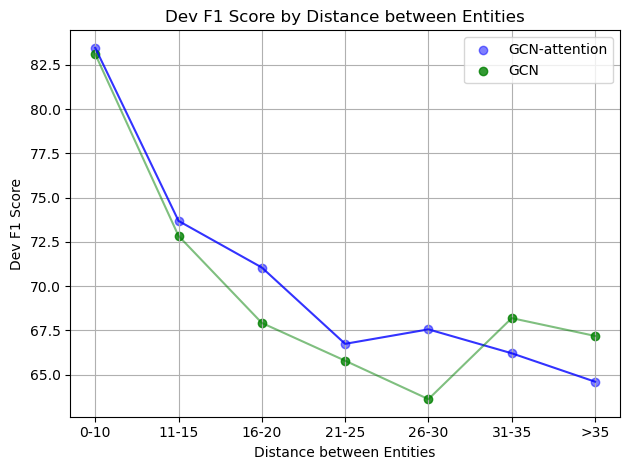

In [ ]:
# plotting 
import matplotlib.pyplot as plt

# data to plot
att_gcn = [83.462, 73.688, 71.056, 66.745, 67.562, 66.212, 64.607]
gcn = [83.110, 72.839, 67.925, 65.792, 63.620, 68.197, 67.192]

fig, ax = plt.subplots()

# create plot
index = list(range(len(att_gcn)))

rects1 = plt.scatter(index, att_gcn, alpha=0.5, color='b', label='GCN-attention', marker='o')
plt.plot(index, att_gcn, alpha=0.8, color='b')

rects2 = plt.scatter(index, gcn, alpha=0.8, color='g', label='GCN', marker='o')
plt.plot(index, gcn, alpha=0.5, color='g')

plt.xlabel('Distance between Entities')
plt.ylabel('Dev F1 Score')
plt.title('Dev F1 Score by Distance between Entities')

#add grid
plt.grid(True)

plt.xticks(index, ('0-10', '11-15', '16-20', '21-25', '26-30', '31-35', '>35'))

plt.legend()
plt.tight_layout()
plt.show()


